# Pseudobulk Differential Expression + Ranked GSEA

Compare two conditions within a chosen cell population, then identify differentially expressed genes and enriched pathways.

**Sign convention:** `condition_a` (the first condition you list below) is the *reference for upregulation*. Positive log2FC and positive NES both mean **higher in `condition_a`**.

## Imports

In [1]:
# pip install pydeseq2 gseapy   # if not yet installed

from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp

import scanpy as sc
import anndata as ad
import spatialdata as spd

import matplotlib.pyplot as plt
import seaborn as sns

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

import gseapy as gp

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## Configuration

Edit the blocks below to control what is compared. Everything downstream reads from these variables.

In [25]:
# ============================================================================
# ── CELLS, CONDITIONS, SAMPLES (edit this block) ────────────────────────────
# ============================================================================

# --- Cells of interest ------------------------------------------------------
# The annotation column and the cell types you want to pool for the DE.
# Multiple cell types are treated as a single population.
celltype_col     = "c2l_permissive"
focus_cell_types = ["M1_like_Mac"]   #           # e.g. ["NK"] or ["CD8_T", "NK"]

# --- Conditions to compare --------------------------------------------------
# IMPORTANT: condition_a is the reference for upregulation.
# Positive log2FC and positive NES => UP in condition_a.
condition_col = "treatment"
condition_a   = "RTCyPSCA_Tu1"      # numerator → "up" direction
condition_b   = "CyPSCA_Tu1"    # denominator

# --- Replicate / pseudobulk grouping ----------------------------------------
# Each unique value in this column becomes one pseudobulk sample.
sample_col    = "tissue"

# --- Optional tissue exclusion ----------------------------------------------
apply_exclusion = False
exclude_tissues = [
    # "CyPSCA_1_3",
    # "RTCyPSCA_1_2",
]

# --- Pseudobulk / DE thresholds --------------------------------------------
min_cells_per_sample = 10     # drop pseudobulk samples with fewer cells
min_total_counts     = 10     # drop genes with low total counts across samples

# --- Output directory -------------------------------------------------------
outdir = Path("/coh_labs/yunroseli/Jona/CAR-T/results/pseudobulk_de")
outdir.mkdir(parents=True, exist_ok=True)

# ============================================================================

print(f"Comparison:  {condition_a}  (positive LFC = up here)  vs  {condition_b}")
print(f"Cell types:  {focus_cell_types}  (column: {celltype_col})")
print(f"Sample col:  {sample_col}")
if apply_exclusion and exclude_tissues:
    print(f"Excluding tissues: {exclude_tissues}")
print(f"Output:      {outdir}")

Comparison:  RTCyPSCA_Tu1  (positive LFC = up here)  vs  CyPSCA_Tu1
Cell types:  ['M1_like_Mac']  (column: c2l_permissive)
Sample col:  tissue
Output:      /coh_labs/yunroseli/Jona/CAR-T/results/pseudobulk_de


## Pathways

In [26]:
# ============================================================================
# ── PATHWAY DATABASES FOR GSEA (edit this block) ────────────────────────────
# ============================================================================

# All available GMT files. Add new entries here as needed.
pathway_libs = {
    "hallmark": Path("/coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/mh.all.v2026.1.Mm.symbols.gmt"),
    "reactome": Path("/coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/m2.cp.reactome.v2026.1.Mm.symbols.gmt"),
    "go_bp":    Path("/coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/m5.go.bp.v2026.1.Mm.symbols.gmt"),
    "kegg":     Path("/coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/m2.cp.v2026.1.Mm.symbols.gmt"),
}

# Pick which of the above to include in the GSEA prerank.
selected_libs = ["go_bp", "kegg"]    # e.g. ["hallmark", "reactome"]

# ============================================================================

def read_gmt(gmt_path):
    sets = {}
    with open(gmt_path) as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            sets[parts[0]] = parts[2:]
    return sets

gene_sets = {}
for lib in selected_libs:
    path = pathway_libs[lib]
    if not path.exists():
        print(f"WARNING: missing GMT for '{lib}': {path}")
        continue
    sets = read_gmt(path)
    print(f"  {lib}: {len(sets):,} sets from {path.name}")
    # Track origin so we can colour bars later
    for k, v in sets.items():
        gene_sets[k] = v

# Lookup table: pathway name -> source library
pathway_source = {}
for lib in selected_libs:
    if pathway_libs[lib].exists():
        for k in read_gmt(pathway_libs[lib]).keys():
            pathway_source.setdefault(k, lib)

print(f"\nTotal gene sets for GSEA: {len(gene_sets):,}")

  go_bp: 7,781 sets from m5.go.bp.v2026.1.Mm.symbols.gmt
  kegg: 1,787 sets from m2.cp.v2026.1.Mm.symbols.gmt

Total gene sets for GSEA: 9,568


## Load data

In [27]:
zarr_file = "/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/processing_Zarr/1_C2l_annotations_400"

sdata = spd.read_zarr(zarr_file)
adata = sdata.tables["segmentation_counts"]

# Preserve raw counts in a layer so pseudobulk uses untransformed counts later,
# regardless of any normalization done elsewhere.
if "counts" not in adata.layers:
    adata.layers["counts"] = adata.X.copy()

del sdata
print(adata)

AnnData object with n_obs × n_vars = 2088557 × 19059
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', 'c2l_argmax', 'c2l_permissive', 'c2l_strict', 'c2l_runnerup', 'c2l_consolidated', 'treatment'
    uns: 'normalization', 'spatialdata_attrs', 'log1p'
    obsm: 'c2l_q95', 'c2l_q05', 'c2l_means', 'spatial'
    layers: 'counts'


## QC: filter low-quality cells

Drop cells with very low UMI counts, very few detected genes, or high mitochondrial fraction. Histograms show distributions with the chosen thresholds (red dashed lines) — adjust thresholds based on what you see.

Mitochondrial genes detected (prefix 'mt-'): 13

Before QC: 2,088,557 cells


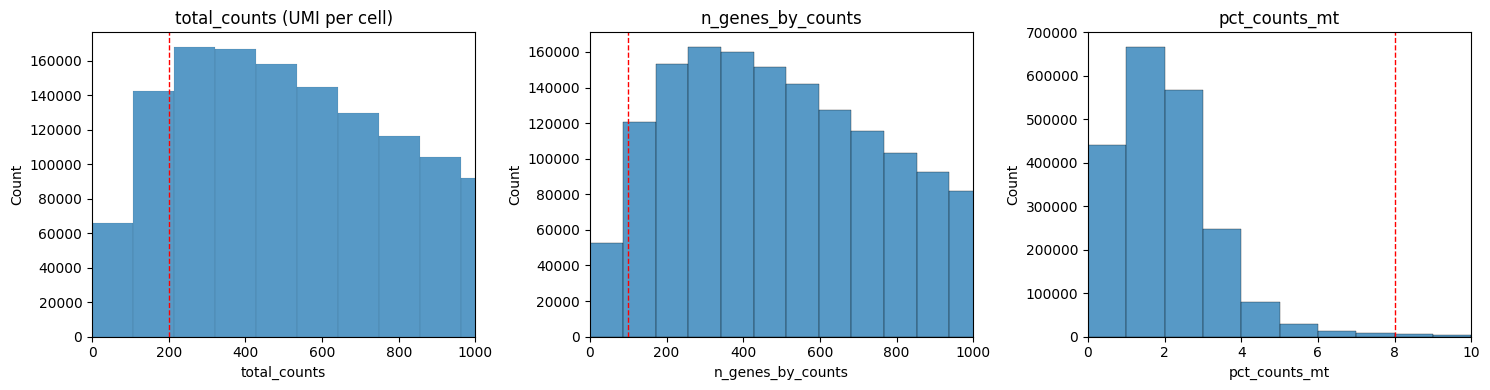

In [28]:
# ── QC thresholds (edit this block) ──────────────────────────────────────────
mt_prefix    = "mt-"     # mouse: "mt-"   human: "MT-"
min_counts   = 200       # min total UMI counts per cell
min_genes    = 100        # min genes detected per cell
max_pct_mt   = 8        # max % mitochondrial reads per cell
# ─────────────────────────────────────────────────────────────────────────────

adata.var["mt"] = adata.var_names.str.startswith(mt_prefix)
print(f"Mitochondrial genes detected (prefix '{mt_prefix}'): {adata.var['mt'].sum()}")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True,
    layer="counts"   # ← always use raw counts
)

print(f"\nBefore QC: {adata.n_obs:,} cells")

# Distribution plots with threshold lines
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(adata.obs["total_counts"], bins=500, ax=axes[0])
axes[0].axvline(min_counts, color="red", ls="--", lw=1)
axes[0].set_title("total_counts (UMI per cell)")
# axes[0].set_xscale("log")
axes[0].set_xlim(0, 1000)

sns.histplot(adata.obs["n_genes_by_counts"], bins=100, ax=axes[1])
axes[1].axvline(min_genes, color="red", ls="--", lw=1)
axes[1].set_title("n_genes_by_counts")
axes[1].set_xlim(0,1000)

sns.histplot(adata.obs["pct_counts_mt"], bins=100, ax=axes[2])
axes[2].axvline(max_pct_mt, color="red", ls="--", lw=1)
axes[2].set_title("pct_counts_mt")
axes[2].set_xlim(0,10)

plt.tight_layout()
plt.show()


In [29]:

# Apply filters
fail_counts = adata.obs["total_counts"]      < min_counts
fail_genes  = adata.obs["n_genes_by_counts"] < min_genes
fail_mt     = adata.obs["pct_counts_mt"]     > max_pct_mt
keep        = ~(fail_counts | fail_genes | fail_mt)

print(f"\nDropped:")
print(f"  low counts (< {min_counts}):     {fail_counts.sum():,}")
print(f"  low genes  (< {min_genes}):      {fail_genes.sum():,}")
print(f"  high mt    (> {max_pct_mt}%):    {fail_mt.sum():,}")
print(f"  total dropped (union):         {(~keep).sum():,}")

adata = adata[keep].copy()

print(f"\nAfter QC: {adata.n_obs:,} cells")


Dropped:
  low counts (< 200):     186,506
  low genes  (< 100):      67,257
  high mt    (> 8%):    33,540
  total dropped (union):         197,556

After QC: 1,891,001 cells


## Normalize

Normalize `adata.X` to 1e4 counts per cell and log1p-transform. **Raw counts are preserved in `adata.layers["counts"]`** and the pseudobulk + DE steps use that layer directly, so DESeq2 sees untransformed counts as required.

In [30]:
# sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)
# sc.pp.log1p(adata)

# adata.uns["normalization"] = {
#     "method": "scanpy.pp.normalize_total + log1p",
#     "target_sum": 1e4,
#     "raw_counts_layer": "counts",
# }

# print("Normalized adata.X (1e4 + log1p). Raw counts still in adata.layers['counts'].")

## Subset to cells of interest

In [31]:
ct_mask   = adata.obs[celltype_col].astype(str).isin(focus_cell_types)
cond_mask = adata.obs[condition_col].astype(str).isin([condition_a, condition_b])

if apply_exclusion and exclude_tissues:
    tissue_mask = ~adata.obs[sample_col].astype(str).isin(exclude_tissues)
else:
    tissue_mask = np.ones(adata.n_obs, dtype=bool)

adata_sub = adata[ct_mask & cond_mask & tissue_mask].copy()

print(f"Cells after filtering: {adata_sub.n_obs:,}")
print()
print("Cells per (condition, sample):")
print(
    adata_sub.obs
    .groupby([condition_col, sample_col], observed=True)
    .size()
    .to_frame("n_cells")
)

Cells after filtering: 6,202

Cells per (condition, sample):
                           n_cells
treatment    tissue               
CyPSCA_Tu1   CyPSCA_1_1       1354
             CyPSCA_1_2        461
             CyPSCA_1_3       1891
             CyPSCA_1_4        118
RTCyPSCA_Tu1 RTCyPSCA_1_2      146
             RTCyPSCA_1_3      474
             RTCyPSCA_1_4     1597
             RTCyPSCA_1_5      161


## Pseudobulk

Sum **raw counts** across cells, grouped by sample. Samples with fewer than `min_cells_per_sample` cells are dropped.

In [32]:
X = adata_sub.layers["counts"]
if sp.issparse(X):
    X = X.toarray()

sample_keys    = adata_sub.obs[sample_col].astype(str).values
condition_keys = adata_sub.obs[condition_col].astype(str).values

# Cells per sample
n_per_sample = pd.Series(sample_keys).value_counts()
valid_samples = n_per_sample[n_per_sample >= min_cells_per_sample].index.tolist()
dropped = n_per_sample[n_per_sample < min_cells_per_sample].to_dict()
if dropped:
    print(f"Dropped samples (< {min_cells_per_sample} cells): {dropped}")

# Build pseudobulk count matrix and metadata
pb_rows = []
pb_meta = []
for s in valid_samples:
    mask = sample_keys == s
    pb_rows.append(X[mask].sum(axis=0))
    pb_meta.append({
        sample_col:    s,
        condition_col: condition_keys[mask][0],
        "n_cells":     int(mask.sum()),
    })

pb_counts_df = pd.DataFrame(
    np.vstack(pb_rows),
    columns=adata_sub.var_names,
    index=[m[sample_col] for m in pb_meta],
).astype(int)
pb_meta_df = pd.DataFrame(pb_meta).set_index(sample_col)

# Drop low-count genes
gene_totals = pb_counts_df.sum(axis=0)
keep_genes  = gene_totals >= min_total_counts
pb_counts_df = pb_counts_df.loc[:, keep_genes]

print(f"Pseudobulk samples: {len(pb_counts_df)}")
print(f"Genes after filter (>= {min_total_counts} total counts): {pb_counts_df.shape[1]:,}")
print()
print("Samples per condition:")
print(pb_meta_df.groupby(condition_col).size())
display(pb_meta_df)

Pseudobulk samples: 8
Genes after filter (>= 10 total counts): 11,931

Samples per condition:
treatment
CyPSCA_Tu1      4
RTCyPSCA_Tu1    4
dtype: int64


,treatment,n_cells
tissue,,
CyPSCA_1_3,CyPSCA_Tu1,1891
RTCyPSCA_1_4,RTCyPSCA_Tu1,1597
CyPSCA_1_1,CyPSCA_Tu1,1354
RTCyPSCA_1_3,RTCyPSCA_Tu1,474
CyPSCA_1_2,CyPSCA_Tu1,461
RTCyPSCA_1_5,RTCyPSCA_Tu1,161
RTCyPSCA_1_2,RTCyPSCA_Tu1,146
CyPSCA_1_4,CyPSCA_Tu1,118


## Differential expression (PyDESeq2)

In [33]:
dds = DeseqDataSet(
    counts=pb_counts_df,
    metadata=pb_meta_df,
    design_factors=condition_col,
    refit_cooks=True,
)
dds.deseq2()

# contrast = [factor, numerator, denominator]  →  log2(numerator / denominator)
# We put condition_a as numerator so positive LFC = UP in condition_a.
ds = DeseqStats(dds, contrast=[condition_col, condition_a, condition_b])
ds.summary()

de_results = (
    ds.results_df
    .dropna(subset=["padj"])
    .sort_values("padj")
)

n_sig    = (de_results["padj"] < 0.05).sum()
n_up_a   = ((de_results["padj"] < 0.05) & (de_results["log2FoldChange"] > 0)).sum()
n_up_b   = ((de_results["padj"] < 0.05) & (de_results["log2FoldChange"] < 0)).sum()

print(f"\nTotal genes tested: {len(de_results):,}")
print(f"Significant (padj < 0.05): {n_sig}")
print(f"  up in {condition_a}: {n_up_a}")
print(f"  up in {condition_b}: {n_up_b}")

de_csv = outdir / f"DE_{'_'.join(focus_cell_types)}_{condition_a}_vs_{condition_b}.csv"
de_results.to_csv(de_csv)
print(f"\nSaved: {de_csv}")
display(de_results.head(20))

Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_980622/2958885072.py:1: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.07 seconds.

Fitting dispersion trend curve...
... done in 0.47 seconds.

Fitting MAP dispersions...
... done in 1.18 seconds.

Fitting LFCs...
... done in 1.66 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: treatment RTCyPSCA_Tu1 vs CyPSCA_Tu1
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Sox17      2.673086        0.124161  0.935569  0.132712  0.894421  0.999869
Lypla1    25.088705        0.353006  0.331019  1.066420  0.286234  0.999869
Tcea1     64.736584       -0.069750  0.230561 -0.302521  0.762255  0.999869
Atp6v1h  104.640919        0.245894  0.195519  1.257649  0.208519  0.999869
Rb1cc1    17.183796        0.494961  0.383420  1.290911  0.196735  0.999869
...             ...             ...       ...       ...       ...       ...
mt-Nd4   238.787841       -0.303544  0.182592 -1.662414  0.096430  0.999869
mt-Nd5   217.081849       -0.120276  0.191287 -0.628774  0.529497  0.999869
mt-Nd6    55.862702       -0.346594  0.258776 -1.339362  0.180453  0.999869
mt-Cytb  703.526913       -0.279000  0.184467 -1.512467  0.130415  0.999869
Vamp7     14.706614       -0.127228  0.421910 -0.301552  0.762994  0.999869

[11931 rows 

... done in 0.70 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Mgp,32.073510,-1.810590,0.366740,-4.936983,7.934027e-07,0.009465
Btbd17,0.855011,-0.261100,1.485188,-0.175803,8.604489e-01,0.999869
Abca9,8.091156,0.269865,0.532793,0.506510,6.124989e-01,0.999869
Abca5,3.502203,-0.402855,0.786093,-0.512477,6.083169e-01,0.999869
Map2k6,8.321942,-0.885977,0.544684,-1.626588,1.038245e-01,0.999869
Kcnj2,2.013679,1.422361,1.020740,1.393460,1.634807e-01,0.999869
Sox9,24.360849,-1.301176,0.386978,-3.362406,7.726651e-04,0.999869
Slc39a11,20.812474,-0.459917,0.361773,-1.271286,2.036270e-01,0.999869
Prkca,6.410139,0.162630,0.594491,0.273562,7.844215e-01,0.999869
Fam104a,39.170009,0.051260,0.273520,0.187410,8.513391e-01,0.999869


In [34]:
display(de_results.head(50))

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Mgp,32.073510,-1.810590,0.366740,-4.936983,7.934027e-07,0.009465
Btbd17,0.855011,-0.261100,1.485188,-0.175803,8.604489e-01,0.999869
Abca9,8.091156,0.269865,0.532793,0.506510,6.124989e-01,0.999869
Abca5,3.502203,-0.402855,0.786093,-0.512477,6.083169e-01,0.999869
Map2k6,8.321942,-0.885977,0.544684,-1.626588,1.038245e-01,0.999869
Kcnj2,2.013679,1.422361,1.020740,1.393460,1.634807e-01,0.999869
Sox9,24.360849,-1.301176,0.386978,-3.362406,7.726651e-04,0.999869
Slc39a11,20.812474,-0.459917,0.361773,-1.271286,2.036270e-01,0.999869
Prkca,6.410139,0.162630,0.594491,0.273562,7.844215e-01,0.999869
Fam104a,39.170009,0.051260,0.273520,0.187410,8.513391e-01,0.999869


## Explore DE genes

Edit the thresholds and `gene_search` to pull out genes of interest.

In [35]:
# ── Editable thresholds ──────────────────────────────────────────────────────
pval_thresh  = 0.05      # padj cutoff
lfc_thresh   = 1.0       # |log2FC| > this
top_n_show   = 30        # rows to display below
gene_search  = []        # e.g. ["Gzmb", "Ifng"]  — look up specific genes
# ─────────────────────────────────────────────────────────────────────────────

sig    = de_results[(de_results["padj"] < pval_thresh) & (de_results["log2FoldChange"].abs() > lfc_thresh)]
up_a   = sig[sig["log2FoldChange"] > 0].sort_values("log2FoldChange", ascending=False)
up_b   = sig[sig["log2FoldChange"] < 0].sort_values("log2FoldChange", ascending=True)

print(f"Up in {condition_a} (top {top_n_show}):")
display(up_a.head(top_n_show))

print(f"\nUp in {condition_b} (top {top_n_show}):")
display(up_b.head(top_n_show))

if gene_search:
    print(f"\nSpecific gene lookup:")
    hits = de_results.loc[de_results.index.isin(gene_search)]
    display(hits)

Up in RTCyPSCA_Tu1 (top 30):


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj



Up in CyPSCA_Tu1 (top 30):


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Mgp,32.07351,-1.81059,0.36674,-4.936983,7.934027e-07,0.009465


## Volcano plot

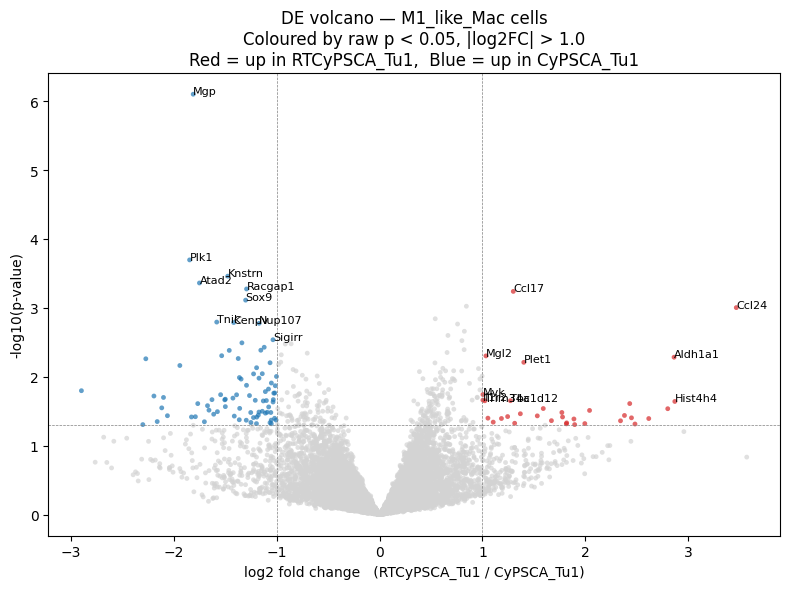

In [36]:
df = de_results.dropna(subset=["pvalue", "log2FoldChange"]).copy()
df["neg_log10_pval"] = -np.log10(df["pvalue"].clip(lower=1e-300))

# Colour by raw p-value (matches the y-axis), not padj.
sig_mask = (df["pvalue"] < pval_thresh) & (df["log2FoldChange"].abs() > lfc_thresh)
color = np.where(
    sig_mask & (df["log2FoldChange"] > 0), "#d62728",         # red    → up in a
    np.where(sig_mask & (df["log2FoldChange"] < 0), "#1f77b4", # blue   → up in b
             "lightgrey"))

# Label the top 10 in each direction by raw p-value among significant genes
sig_df    = df[sig_mask]
label_up  = sig_df[sig_df["log2FoldChange"] > 0].nsmallest(10, "pvalue")
label_dn  = sig_df[sig_df["log2FoldChange"] < 0].nsmallest(10, "pvalue")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["log2FoldChange"], df["neg_log10_pval"], c=color, s=12, alpha=0.7, edgecolors="none")

for gene, row in pd.concat([label_up, label_dn]).iterrows():
    ax.annotate(
        gene,
        (row["log2FoldChange"], -np.log10(max(row["pvalue"], 1e-300))),
        fontsize=8,
    )

ax.axhline(-np.log10(pval_thresh), ls="--", c="grey", lw=0.5)
ax.axvline( lfc_thresh, ls="--", c="grey", lw=0.5)
ax.axvline(-lfc_thresh, ls="--", c="grey", lw=0.5)

ax.set_xlabel(f"log2 fold change   ({condition_a} / {condition_b})")
ax.set_ylabel("-log10(p-value)")
ax.set_title(
    f"DE volcano — {' + '.join(focus_cell_types)} cells\n"
    f"Coloured by raw p < {pval_thresh}, |log2FC| > {lfc_thresh}\n"
    f"Red = up in {condition_a},  Blue = up in {condition_b}"
)
plt.tight_layout()
plt.show()

fig.savefig(outdir / f"volcano_{'_'.join(focus_cell_types)}_{condition_a}_vs_{condition_b}.png",
            dpi=200, bbox_inches="tight")

## Ranked GSEA (prerank)

Genes are ranked by `sign(log2FC) × -log10(pvalue)`, which combines fold-change **direction** with statistical **significance**. Positive NES means the pathway is enriched at the top of the ranked list — i.e. **up in `condition_a`**.

In [37]:
# ── Editable: which libraries to enrich + leniency knobs ─────────────────────
# Defaults to all libraries you loaded in the config. Override to subset, e.g.
enrich_libs = ["hallmark", "reactome", "go_bp", "kegg"] #hallmark, rectome, go_bp, kegg
# enrich_libs = list(selected_libs)

# Spatial / low-n leniency:
# - small min_size so focused gene sets aren't pre-filtered out
# - more permutations for stable enrichment p-values with noisy ranks
gsea_min_size     = 5
gsea_max_size     = 500
gsea_permutations = 2000
# ─────────────────────────────────────────────────────────────────────────────

# Build the ranked gene list once (sign(LFC) * -log10(pvalue))
rank_df = de_results.dropna(subset=["log2FoldChange", "pvalue"]).copy()
pvals = rank_df["pvalue"].clip(lower=1e-300)
rank_df["score"] = np.sign(rank_df["log2FoldChange"]) * -np.log10(pvals)

rnk = (
    rank_df[["score"]]
    .reset_index()
    .rename(columns={rank_df.index.name or "index": "gene"})
    .sort_values("score", ascending=False)
    .drop_duplicates(subset="gene")
)

# Run prerank once per library so results stay separable
gsea_results_by_lib = {}

for lib in enrich_libs:
    libpath = pathway_libs[lib]
    if not libpath.exists():
        print(f"  skipping {lib} (file not found: {libpath})")
        continue

    lib_sets = read_gmt(libpath)
    print(f"  prerank on {lib}: {len(lib_sets):,} gene sets...")

    pre_res = gp.prerank(
        rnk=rnk,
        gene_sets=lib_sets,
        threads=4,
        min_size=gsea_min_size,
        max_size=gsea_max_size,
        permutation_num=gsea_permutations,
        outdir=None,
        seed=42,
        verbose=False,
    )

    df = pre_res.res2d.copy()

    # Coerce numerics
    for col in ("ES", "NES", "NOM p-val", "FDR q-val", "FWER p-val"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Normalize pathway-name column across gseapy versions
    if "Term" in df.columns:
        df = df.rename(columns={"Term": "pathway"})
    elif "Name" in df.columns:
        df = df.rename(columns={"Name": "pathway"})
    else:
        df = df.reset_index().rename(columns={"index": "pathway"})

    df["source"] = lib
    df = df.sort_values("NES", ascending=False)   # positive NES (up in condition_a) first

    gsea_results_by_lib[lib] = df

# Combined dataframe: sort by source then NES descending so the top of each
# library block is what is UP in condition_a (positive NES) — which is what we
# care about. Down-regulated pathways are still in the CSV; scroll to the
# bottom of each library group to see them.
gsea_df = (
    pd.concat(gsea_results_by_lib.values(), ignore_index=True)
    .sort_values(["source", "NES"], ascending=[True, False])
)

fdr_col = "FDR q-val" if "FDR q-val" in gsea_df.columns else "fdr"

# Per-library summary at multiple FDR thresholds
print(f"\n=== GSEA summary per library ===")
print(f"{'library':<12} {'tested':>7} {'FDR<0.05':>9} {'FDR<0.25':>9} {'FDR<0.5':>8}")
for lib, df in gsea_results_by_lib.items():
    print(f"{lib:<12} {len(df):>7} "
          f"{(df[fdr_col] < 0.05).sum():>9} "
          f"{(df[fdr_col] < 0.25).sum():>9} "
          f"{(df[fdr_col] < 0.5).sum():>8}")

gsea_csv = outdir / f"GSEA_{'_'.join(focus_cell_types)}_{condition_a}_vs_{condition_b}.csv"
gsea_df.to_csv(gsea_csv, index=False)
print(f"\nSaved combined: {gsea_csv}")

# Per-library tables: separate UP-in-condition_a (positive NES) from
# UP-in-condition_b (negative NES). The up-in-a tables are the primary view.
show_top_n        = 15
show_down_tables  = True   # set False to hide the "up in condition_b" tables

for lib, df in gsea_results_by_lib.items():
    cols = [c for c in ["pathway", "NES", "NOM p-val", fdr_col, "Tag %", "Gene %", "Lead_genes"] if c in df.columns]

    up_in_a = df[df["NES"] > 0].sort_values("NES", ascending=False).head(show_top_n)
    print(f"\n--- {lib}: top {len(up_in_a)} UP in {condition_a} (positive NES) ---")
    display(up_in_a[cols])

    if show_down_tables:
        up_in_b = df[df["NES"] < 0].sort_values("NES", ascending=True).head(show_top_n)
        print(f"--- {lib}: top {len(up_in_b)} UP in {condition_b} (negative NES) ---")
        display(up_in_b[cols])

2026-05-17 20:11:13,858 [WARNING] Duplicated values found in preranked stats: 0.16% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  prerank on hallmark: 50 gene sets...


2026-05-17 20:11:16,798 [WARNING] Duplicated values found in preranked stats: 0.16% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  prerank on reactome: 1,333 gene sets...


2026-05-17 20:11:51,868 [WARNING] Duplicated values found in preranked stats: 0.16% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


...

,pathway,NES,NOM p-val,FDR q-val,Tag %,Gene %,Lead_genes
0,GOBP_SISTER_CHROMATID_SEGREGATION,-2.552888,0.0005,0.0005,97/216,18.09%,Plk1;Knstrn;Racgap1;Top2a;Cenpa;Ube2c;Ska2;Myb...
1,GOBP_MITOTIC_SISTER_CHROMATID_SEGREGATION,-2.517956,0.0005,0.0005,83/182,18.09%,Plk1;Knstrn;Racgap1;Cenpa;Ube2c;Ska2;Mybl2;Kif...
2,GOBP_NUCLEAR_CHROMOSOME_SEGREGATION,-2.460062,0.0005,0.0005,110/272,16.30%,Plk1;Knstrn;Racgap1;Cenpv;Top2a;Ccnb2;Cenpa;Ub...
3,GOBP_CHROMOSOME_SEGREGATION,-2.439107,0.0005,0.0005,138/371,16.30%,Plk1;Knstrn;Racgap1;Cenpv;Top2a;Ccnb2;Cenpa;Ub...
4,GOBP_SPINDLE_ASSEMBLY,-2.376291,0.0005,0.0005,47/133,14.41%,Plk1;Racgap1;Cenpv;Ccnb2;Ska2;Mybl2;Kif11;Cdc2...
5,GOBP_REGULATION_OF_SISTER_CHROMATID_SEGREGATION,-2.372616,0.0005,0.0005,44/94,15.76%,Plk1;Ube2c;Cdc20;Tacc3;Bcl7a;Numa1;Bub1;Cdc6;K...
6,GOBP_CHROMOSOME_ORGANIZATION,-2.362906,0.0005,0.0005,172/471,17.29%,Plk1;Knstrn;Racgap1;Cenpv;Nup107;Top2a;Cenpa;U...
7,GOBP_METAPHASE_CHROMOSOME_ALIGNMENT,-2.351145,0.0005,0.0005,43/98,14.61%,Knstrn;Racgap1;Cenpv;Cenpa;Ska2;Nup62;Cenpf;Nu...
8,GOBP_MITOTIC_NUCLEAR_DIVISION,-2.345256,0.0005,0.0005,102/253,18.09%,Plk1;Knstrn;Racgap1;Cenpa;Ube2c;Ska2;Mybl2;Ube...
10,GOBP_REGULATION_OF_CHROMOSOME_SEGREGATION,-2.321262,0.0005,0.0005,51/118,15.76%,Plk1;Ube2c;Cdc20;Tacc3;Bcl7a;Ncapg;Numa1;Bub1;...



--- kegg: top 15 UP in RTCyPSCA_Tu1 (positive NES) ---


,pathway,NES,NOM p-val,FDR q-val,Tag %,Gene %,Lead_genes
23,WP_TYROBP_CAUSAL_NETWORK_IN_MICROGLIA,2.164560,0.000500,0.001042,27/53,16.76%,Elf4;Maf;Tmem106a;Loxl3;Cd84;Rbm47;Pycard;Tcir...
29,REACTOME_CHEMOKINE_RECEPTORS_BIND_CHEMOKINES,2.081398,0.000500,0.003387,16/30,13.06%,Ccl17;Ccl7;Pf4;Cxcl12;Ccr5;Ccl11;Ppbp;Cxcl16;C...
31,WP_MICROGLIA_PATHOGEN_PHAGOCYTOSIS_PATHWAY,2.079793,0.000500,0.002258,25/41,24.40%,C1qa;Fcer1g;C1qb;Vav1;Itgam;Trem2;Cyba;Nckap1l...
35,REACTOME_CLASS_A_1_RHODOPSIN_LIKE_RECEPTORS,2.061119,0.000500,0.002996,36/117,13.06%,Ccl17;Cmklr1;Ccl7;Pf4;Htr2a;Avpr1a;C3ar1;Cxcl1...
39,REACTOME_PEPTIDE_LIGAND_BINDING_RECEPTORS,2.044162,0.000500,0.003648,26/66,13.06%,Ccl17;Ccl7;Pf4;Avpr1a;C3ar1;Cxcl12;Ccr5;Ccl11;...
40,REACTOME_ROS_AND_RNS_PRODUCTION_IN_PHAGOCYTES,2.033820,0.000500,0.004603,18/27,21.44%,Atp6v0c;Atp6v1b2;Tcirg1;Cyba;Slc11a1;Ncf1;Atp6...
52,REACTOME_INSULIN_RECEPTOR_RECYCLING,1.954013,0.000500,0.018164,17/23,25.12%,Atp6v0c;Atp6v1b2;Tcirg1;Ptpn1;Atp6v1h;Atp6v0a1...
57,REACTOME_NEUTROPHIL_DEGRANULATION,1.934138,0.000500,0.021496,126/389,16.19%,Pnp;Adam8;Hexb;Plau;Mgst1;Fcgr2b;Hpse;Grn;Ist1...
63,WP_COMPLEMENT_AND_COAGULATION_CASCADES,1.894909,0.000983,0.035551,12/34,6.38%,Plau;Serping1;C2;C3ar1;Cfb;C1qa;C1ra;C1qb;F7;C...
66,REACTOME_TRANSFERRIN_ENDOCYTOSIS_AND_RECYCLING,1.876437,0.000500,0.042991,15/25,21.44%,Atp6v0c;Atp6v1b2;Tcirg1;Hfe;Atp6v1h;Atp6v0a1;A...


--- kegg: top 15 UP in CyPSCA_Tu1 (negative NES) ---


,pathway,NES,NOM p-val,FDR q-val,Tag %,Gene %,Lead_genes
0,REACTOME_MITOTIC_PROMETAPHASE,-2.405217,0.0005,0.0005,73/179,17.15%,Plk1;Nup107;Ccnb2;Cenpa;Ska2;Cdc20;Cenpf;Alms1...
1,REACTOME_SNRNP_ASSEMBLY,-2.386695,0.0005,0.0005,26/46,18.95%,Nup107;Snrpf;Snrpd3;Nup62;Prmt5;Snrpd2;Nup155;...
2,REACTOME_MITOTIC_SPINDLE_CHECKPOINT,-2.382583,0.0005,0.0005,50/104,17.81%,Plk1;Nup107;Cenpa;Ube2c;Ska2;Ube2s;Cdc20;Cenpf...
3,REACTOME_CELL_CYCLE_CHECKPOINTS,-2.366616,0.0005,0.0005,86/235,15.24%,Plk1;Nup107;Ccnb2;Cenpa;Ube2c;Ska2;Ube2s;Cdc20...
4,REACTOME_MITOCHONDRIAL_TRANSLATION,-2.353831,0.0005,0.0005,12/27,5.75%,mt-Co2;mt-Co3;Ptcd3;mt-Atp6;mt-Nd1;mt-Atp8;mt-...
5,REACTOME_RESOLUTION_OF_SISTER_CHROMATID_COHESION,-2.320652,0.0005,0.0005,45/110,13.81%,Plk1;Nup107;Ccnb2;Cenpa;Ska2;Cdc20;Cenpf;Bub1;...
6,REACTOME_AMPLIFICATION_OF_SIGNAL_FROM_THE_KINE...,-2.320094,0.0005,0.0005,41/88,16.04%,Plk1;Nup107;Cenpa;Ska2;Cdc20;Cenpf;Bub1;Kntc1;...
7,REACTOME_CELL_CYCLE_MITOTIC,-2.302459,0.0005,0.0005,137/425,15.24%,Plk1;Nup107;Ccnb2;Hmmr;Cenpa;Ube2c;Ska2;Lmnb1;...
8,REACTOME_MAJOR_PATHWAY_OF_RRNA_PROCESSING_IN_T...,-2.283694,0.0005,0.0005,48/88,21.94%,Nol11;Nop58;Bms1;Utp4;Dhx37;Ncl;Ddx21;Ftsj3;No...
9,REACTOME_TRANSPORT_OF_MATURE_TRANSCRIPT_TO_CYT...,-2.266004,0.0005,0.0005,34/74,19.11%,Nup107;Nup62;Nxt1;Alyref;Slbp;Srsf1;Nup155;Cps...


## Per-library pathway plots

One figure per enriched library. Use this to see which signals come from which database.

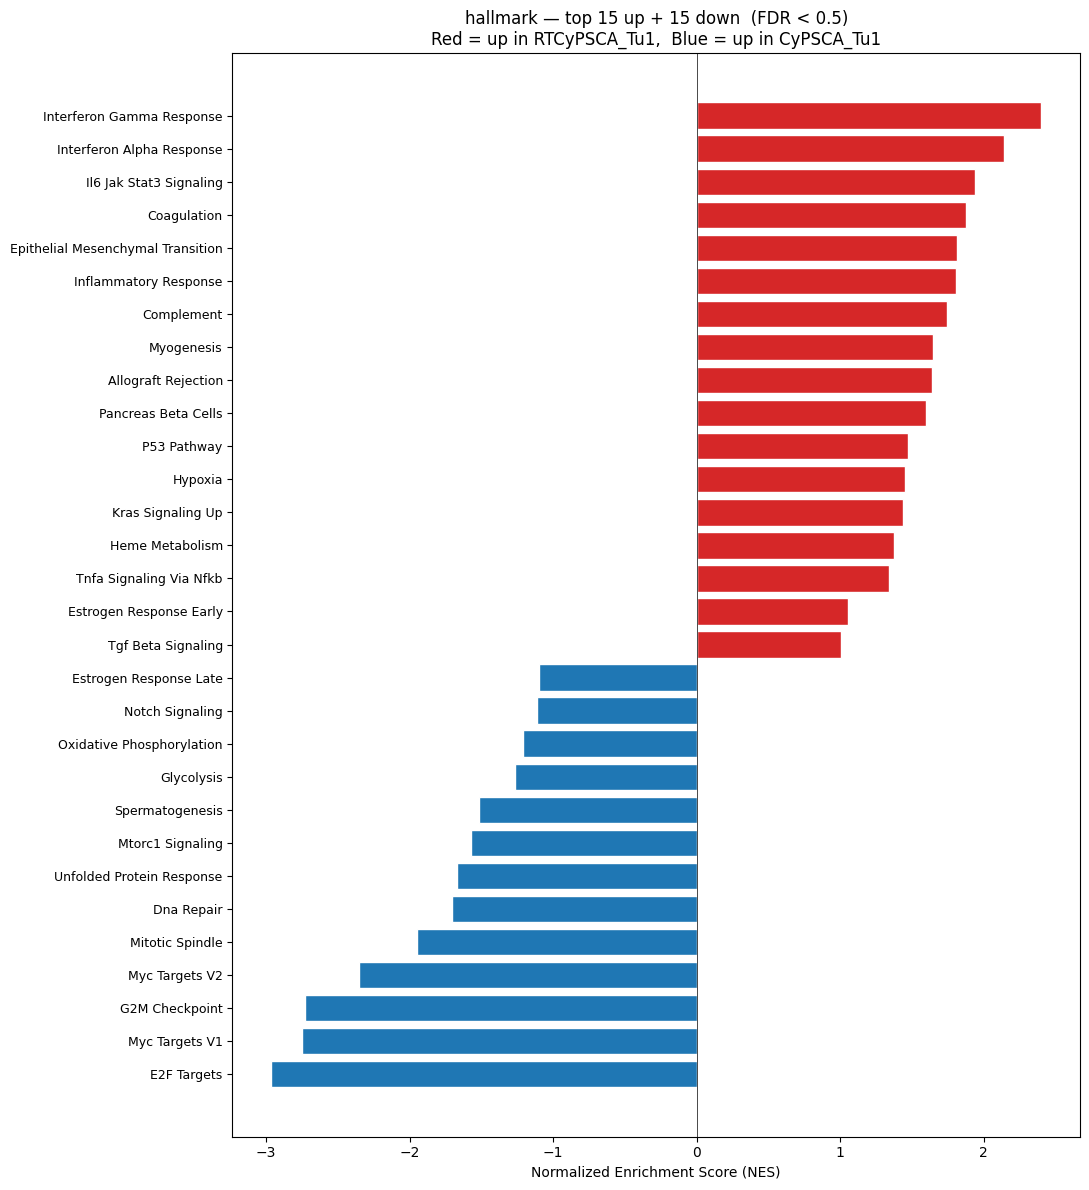

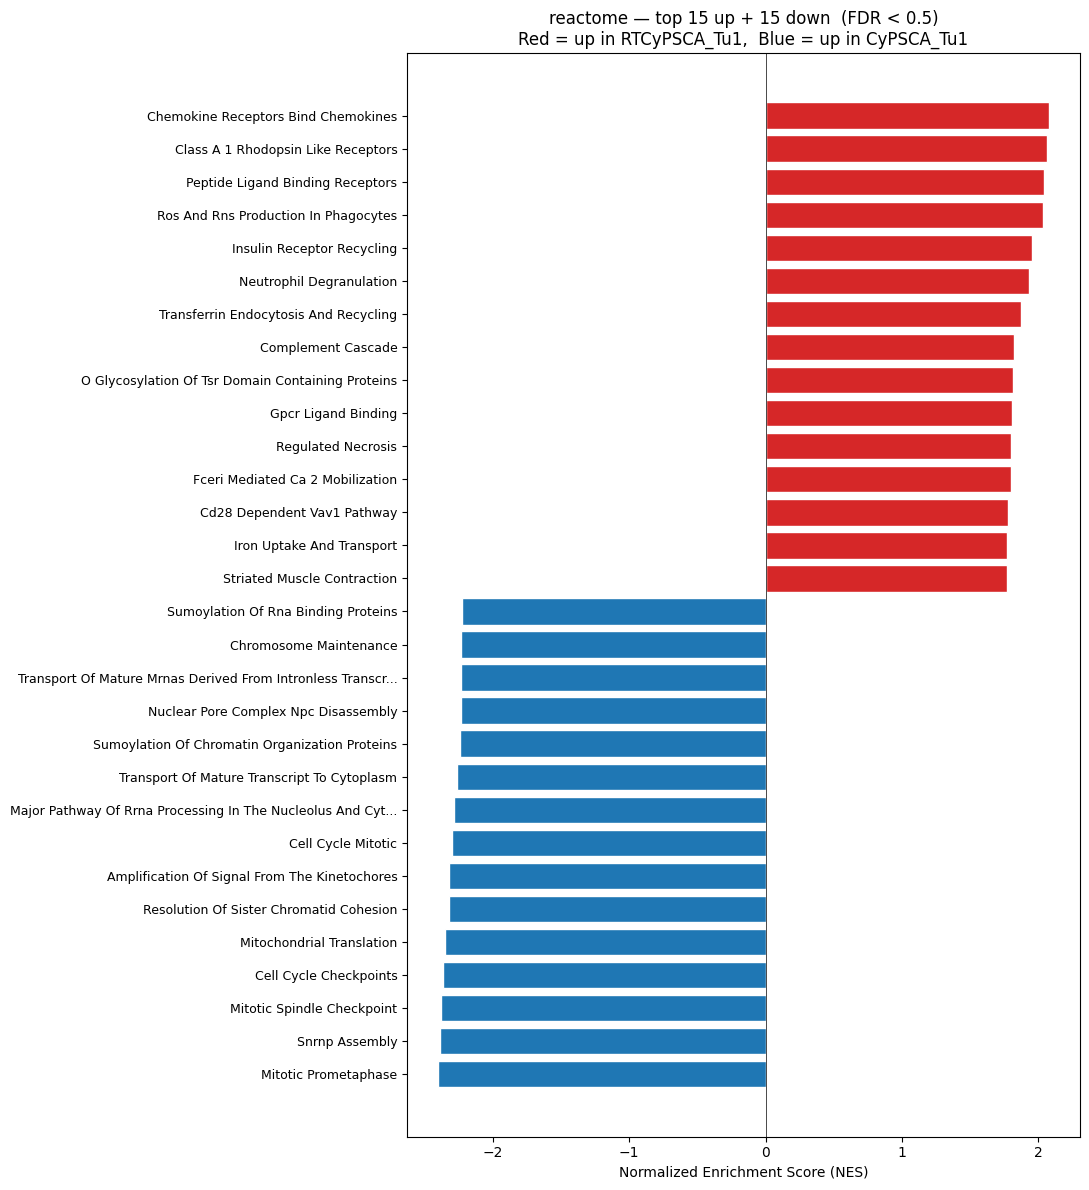

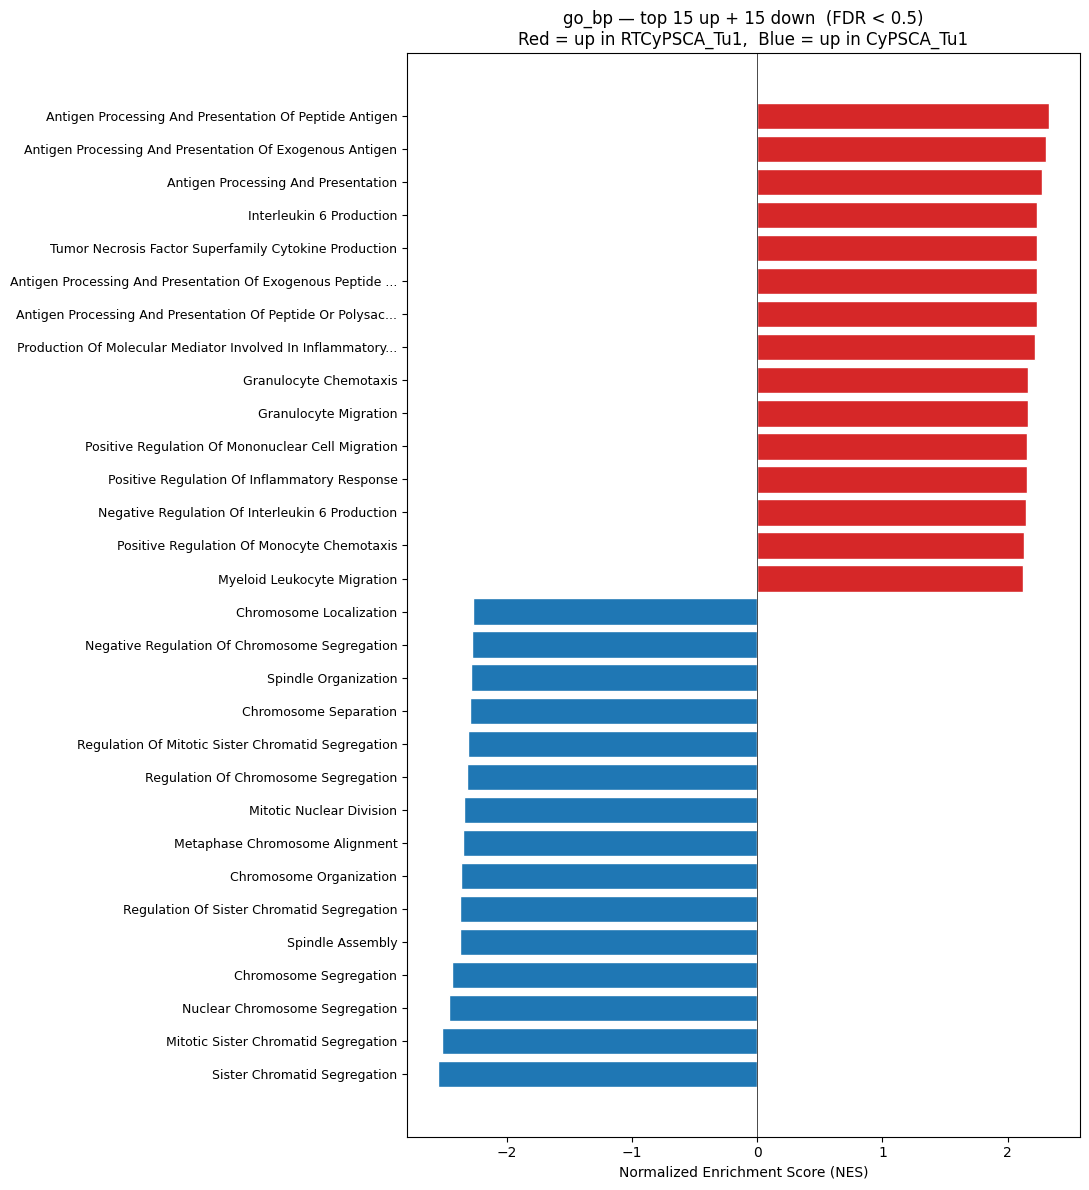

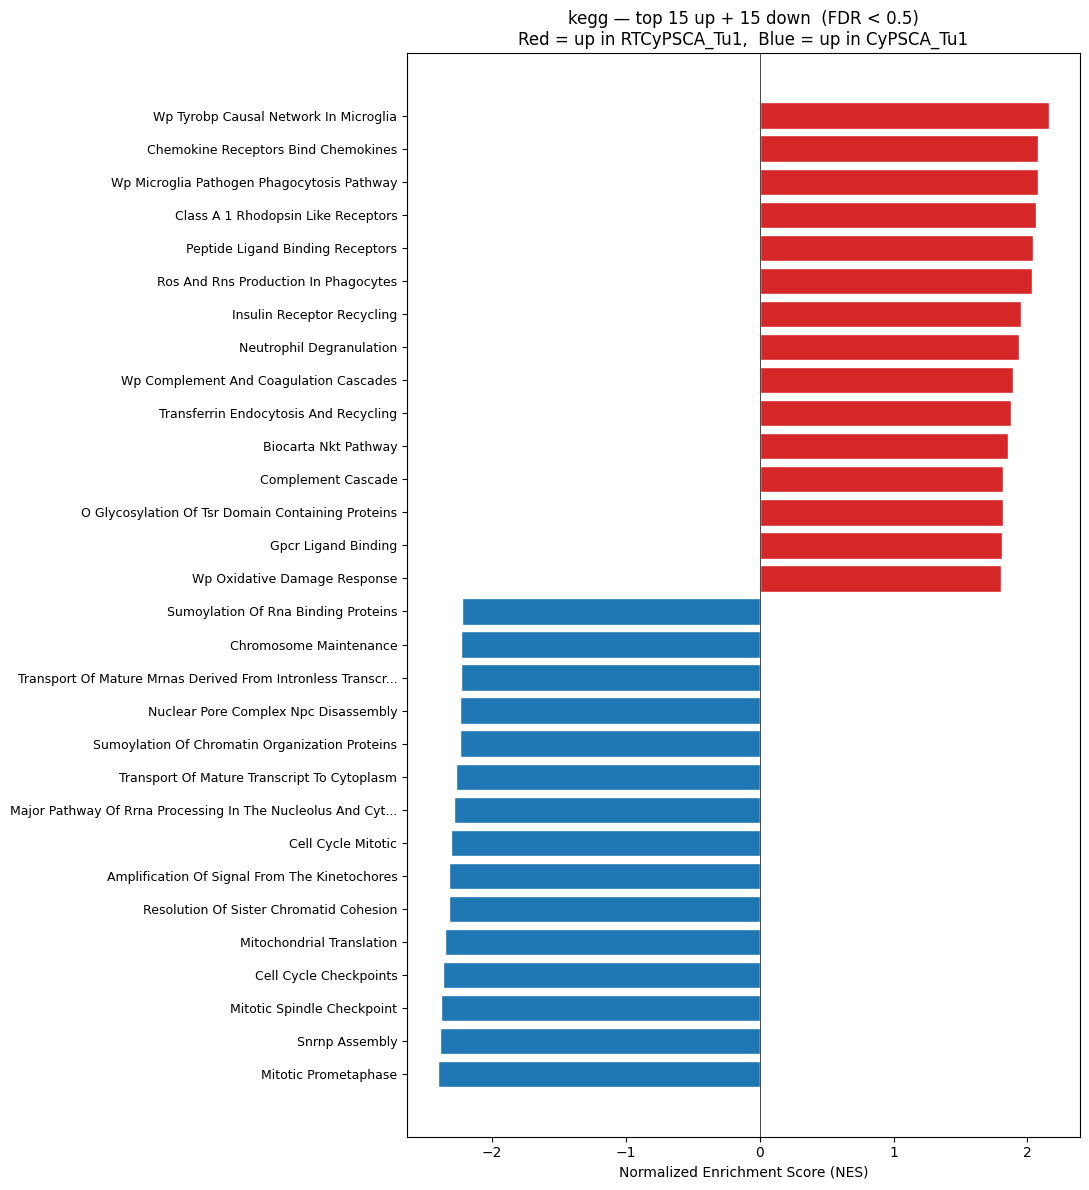

In [38]:
# ── Editable: per-library bar plots (one figure per library) ─────────────────
# Pick which libraries to plot — defaults to everything you enriched.
plot_libs    = list(gsea_results_by_lib.keys())

n_each       = 15        # top N up + top N down per library
fdr_cutoff   = 0.5       # lenient default. Set to None to skip FDR filter
clean_names  = True
# ─────────────────────────────────────────────────────────────────────────────

def _clean(name):
    s = name
    for prefix in ("HALLMARK_", "REACTOME_", "GOBP_", "GOMF_", "GOCC_", "KEGG_"):
        if s.startswith(prefix):
            s = s[len(prefix):]
            break
    s = s.replace("_", " ").title()
    if len(s) > 60:
        s = s[:57] + "..."
    return s

for lib in plot_libs:
    df = gsea_results_by_lib.get(lib)
    if df is None or df.empty:
        print(f"[{lib}] no results")
        continue

    g = df.copy()
    if fdr_cutoff is not None:
        g = g[g[fdr_col] < fdr_cutoff]

    top_up   = g.nlargest(n_each, "NES")
    top_down = g.nsmallest(n_each, "NES")

    if top_up.empty and top_down.empty:
        print(f"[{lib}] no pathways pass FDR < {fdr_cutoff}")
        continue
    if len(top_up) < n_each or len(top_down) < n_each:
        print(f"[{lib}] only {len(top_up)} up / {len(top_down)} down pass FDR < {fdr_cutoff}")

    combined = pd.concat([top_up, top_down]).sort_values("NES")
    combined["display"] = combined["pathway"].apply(_clean) if clean_names else combined["pathway"]

    fig, ax = plt.subplots(figsize=(11, 0.35 * len(combined) + 1.5))
    y = np.arange(len(combined))
    bar_colors = ["#d62728" if v > 0 else "#1f77b4" for v in combined["NES"]]
    ax.barh(y, combined["NES"], color=bar_colors, edgecolor="white")
    ax.set_yticks(y)
    ax.set_yticklabels(combined["display"], fontsize=9)
    ax.axvline(0, color="black", lw=0.5)
    ax.set_xlabel("Normalized Enrichment Score (NES)")
    ax.set_title(
        f"{lib} — top {len(top_up)} up + {len(top_down)} down"
        + (f"  (FDR < {fdr_cutoff})" if fdr_cutoff is not None else "")
        + f"\nRed = up in {condition_a},  Blue = up in {condition_b}"
    )
    plt.tight_layout()
    plt.show()

    fig.savefig(
        outdir / f"GSEA_{lib}_top{len(combined)}_{'_'.join(focus_cell_types)}_{condition_a}_vs_{condition_b}.png",
        dpi=200, bbox_inches="tight",
    )

## Combined pathway plot

All libraries competing in one figure. Useful for spotting the dominant signal across databases.

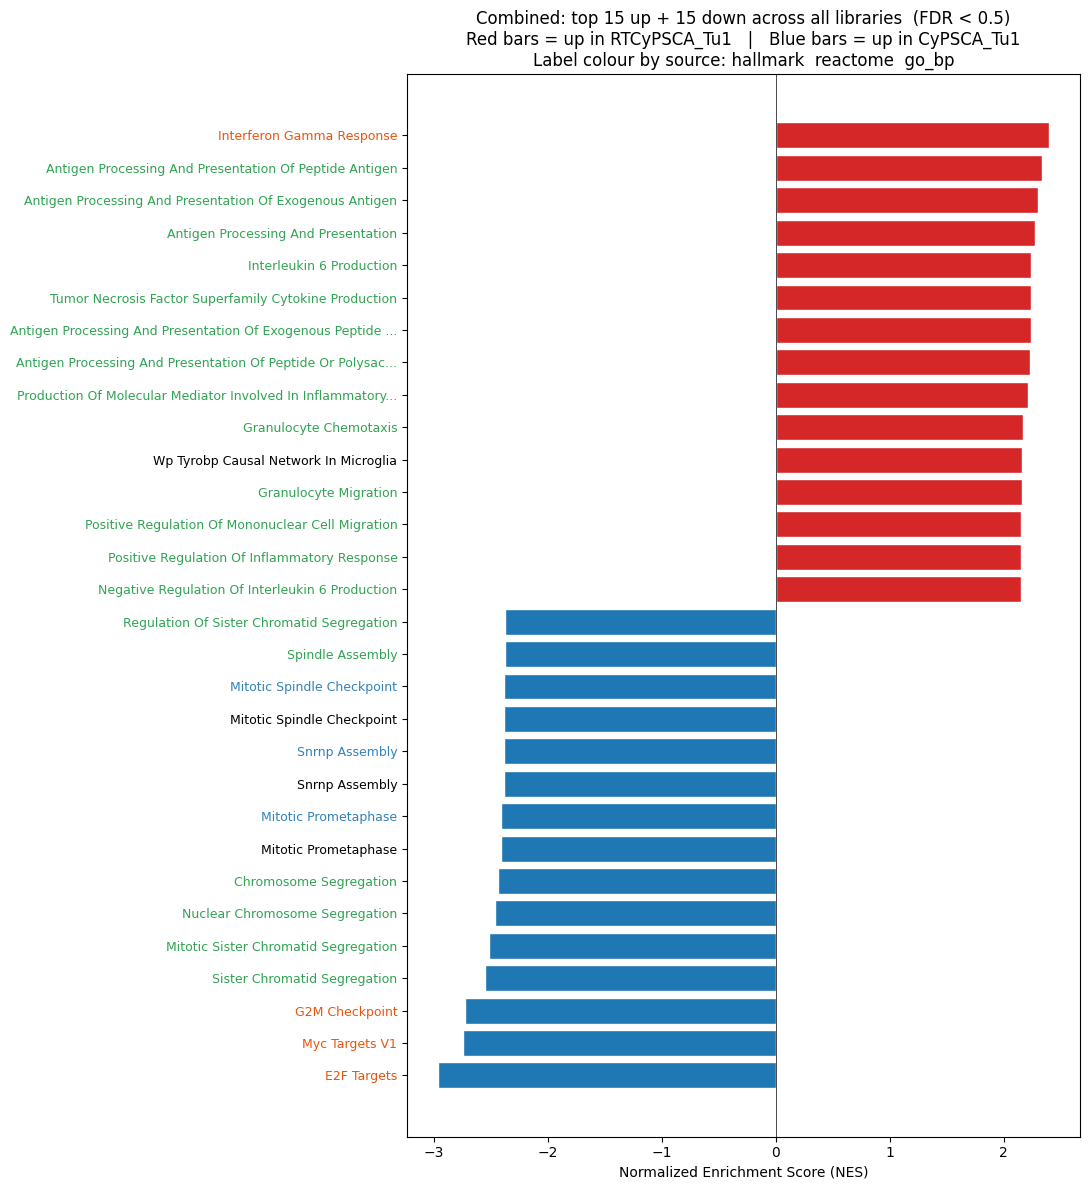

In [41]:
# ── Editable: combined view across all libraries ─────────────────────────────
# This view answers "what are the strongest signals overall?" by competing all
# enriched libraries against each other.
n_each      = 15
fdr_cutoff  = 0.5        # lenient — low n + bleed-over means raw FDR is harsh
clean_names = True
# ─────────────────────────────────────────────────────────────────────────────

g = gsea_df.copy()
if fdr_cutoff is not None:
    g = g[g[fdr_col] < fdr_cutoff]

top_up   = g.nlargest(n_each, "NES")
top_down = g.nsmallest(n_each, "NES")

if len(top_up) < n_each or len(top_down) < n_each:
    print(f"Only {len(top_up)} up and {len(top_down)} down pathways passed FDR < {fdr_cutoff}.")

combined = pd.concat([top_up, top_down]).sort_values("NES")

def _clean(name):
    s = name
    for prefix in ("HALLMARK_", "REACTOME_", "GOBP_", "GOMF_", "GOCC_", "KEGG_"):
        if s.startswith(prefix):
            s = s[len(prefix):]
            break
    s = s.replace("_", " ").title()
    if len(s) > 60:
        s = s[:57] + "..."
    return s

combined["display"] = combined["pathway"].apply(_clean) if clean_names else combined["pathway"]

source_colors = {
    "hallmark": "#e6550d",
    "reactome": "#3182bd",
    "go_bp":    "#31a354",
}

fig, ax = plt.subplots(figsize=(11, 0.35 * len(combined) + 1.5))
y = np.arange(len(combined))
bar_colors = ["#d62728" if v > 0 else "#1f77b4" for v in combined["NES"]]
ax.barh(y, combined["NES"], color=bar_colors, edgecolor="white")

# Tick label colour by source library
ytick_colors = [source_colors.get(s, "black") for s in combined["source"]]
ax.set_yticks(y)
ax.set_yticklabels(combined["display"], fontsize=9)
for tick, c in zip(ax.get_yticklabels(), ytick_colors):
    tick.set_color(c)

ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Normalized Enrichment Score (NES)")
ax.set_title(
    f"Combined: top {n_each} up + {n_each} down across all libraries  (FDR < {fdr_cutoff})\n"
    f"Red bars = up in {condition_a}   |   Blue bars = up in {condition_b}\n"
    f"Label colour by source: "
    + "  ".join(f"{lib}" for lib in plot_libs if lib in source_colors)
)
plt.tight_layout()
plt.show()

fig.savefig(
    outdir / f"GSEA_combined_top{n_each*2}_{'_'.join(focus_cell_types)}_{condition_a}_vs_{condition_b}.png",
    dpi=200, bbox_inches="tight",
)